## Project overview
With the rapid rise of AI-generated content, phishing emails have become more sophisticated and harder to detect through traditional methods. Attackers now craft deceptive messages that closely mimic legitimate communication, putting individuals and organizations at risk of data theft, financial fraud, and identity compromise. This project aims to address the growing threat by developing an intelligent phishing email detection system using RoBERTa, a powerful transformer-based language model. By analyzing the textual content of emails, our model learns to distinguish between phishing and legitimate messages with high accuracy, helping to automate and enhance email security on a large scale.

# 📚 Phishing Email Detection using RoBERTa+XGBoost - Project Notebook

## 📌 Table of Contents

1. [Project Overview](#project-overview)
2. [Environment Setup](#environment-setup)
3. [Data Loading and Sampling](#data-loading-and-sampling)
4. [Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)
    - [Label Distribution](#label-distribution)
    - [Text Length Analysis](#text-length-analysis)
    - [Special Characters & URL Analysis](#special-characters--url-analysis)
    - [Top Words in Phishing Emails](#top-words-in-phishing-emails)
5. [Data Preprocessing](#data-preprocessing)
    - [Lowercasing](#lowercasing)
    - [Stopwords Removal (Optional)](#stopwords-removal-optional)
6. [Train-Validation-Test Split (70/10/20)](#train-validation-test-split-701020)
7. [Tokenization using RoBERTa Tokenizer](#tokenization-using-bert-tokenizer)
8. [Dataset Preparation for PyTorch](#dataset-preparation-for-pytorch)
9. [Model Setup with RoBERTa](#model-setup-with-bert)
10. [Define Training Arguments](#define-training-arguments)
11. [Trainer Setup and Metrics](#trainer-setup-and-metrics)
12. [Model Training](#model-training)
13. [Evaluate on Validation Set](#evaluate-on-validation-set)
14. [Evaluate on Test Set](#evaluate-on-test-set)
    - [Accuracy, Precision, Recall, F1-Score](#accuracy-precision-recall-f1-score)
    - [Confusion Matrix](#confusion-matrix)
15. [Plot Metrics (Accuracy/Loss vs Epoch)](#plot-metrics-accuracyloss-vs-epoch)
16. [Saving the Model and Tokenizer](#saving-the-model-and-tokenizer)
17
18. [Load Trained Model for Inference](#load-trained-model-for-inference)
19. [Next Steps and Improvements](#next-steps-and-improvements)


## Summary:

### Data Analysis Key Findings

*   RoBERTa, a refined version of BERT, was explored as an alternative model and successfully integrated into the process, showing potential for improved performance due to its larger training data and dynamic masking strategy.
*   Custom stylometry features (average word length, average sentence length, uppercase ratio, punctuation count, digit count) were successfully extracted from the email text.
*   A GPT-2 based perplexity score was calculated for emails, serving as a feature to potentially identify AI-generated content.
*   Simulated metadata analysis features (WHOIS, SPF/DKIM, URL entropy) were implemented and extracted from the email text, adding external context to the analysis.
*   An ensemble model combining RoBERTa and XGBoost was built. This model utilizes RoBERTa's text classification capabilities and XGBoost's ability to leverage the extracted stylometry, perplexity, and simulated metadata features.
*   The ensemble model achieved an Accuracy of 0.9253, Precision of 0.9217, Recall of 0.9359, and F1 Score of 0.9287 on the test set.
*   The training data was successfully augmented with 2,000 simulated phishing emails (real, AI-generated, and adversarial), increasing the training set size to 12,500 and significantly increasing the representation of the phishing class.

*   The ensemble model shows promising performance, suggesting that combining different types of features (textual embeddings, stylometry, metadata) and models can enhance phishing detection accuracy. Further hyperparameter tuning of both base models and the meta-classifier could potentially improve results.
*   While the data augmentation increased the phishing class representation and was used for RoBERTa training, evaluating the impact of training the XGBoost model and/or the meta-classifier on this augmented data could be a valuable next step.


In [1]:
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"  # Must be set first
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Now import other libraries
import pandas as pd
import re
import torch
import seaborn as sns
import matplotlib.pyplot as plt

# Transformers (Hugging Face)

from transformers import Trainer, TrainingArguments, DataCollatorWithPadding
from transformers import RobertaTokenizer, RobertaForSequenceClassification


# Scikit-learn and Datasets

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from datasets import Dataset
from lightgbm import LGBMClassifier


In [2]:
# Example: Load a CSV dataset

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/CEAS_08.csv')


df.shape

Mounted at /content/drive


(39154, 7)

In [3]:
# Randomly sample 15,000 rows from the full dataset
#df = df.sample(n=15000, random_state=42).reset_index(drop=True)

#print(df.head())

## Preprocess the Data

- **Remove null**
- **Lowercasing** : BERT handles case, but lowercase helps traditional models


# Preprocessing Steps Not Applied (with Justifications)

- **Remove URLs** : URLs are strong indicators of phishing, so we keep them as features.
- **Remove special characters** : Symbols like @, !, $, etc., are commonly used in phishing tactics and should be retained.
- **Remove punctuation** : Punctuation may be part of deceptive formatting or URLs, so we do not remove it.
- **Remove numbers** : Numbers (like fake invoice IDs or OTPs) may signal phishing intent, so we preserve them.
- **Remove stopwords** : Common words may carry phishing signals in certain contexts, so we keep them for now.
- **Remove capital letters** : Capitalization (e.g., “URGENT”) often indicates phishing, so we retain letter casing.
- **Stemming or Lemmatization** : We keep words in their original form to preserve possible phishing-related phrasing.
- **Remove HTML tags** : Some phishing emails use HTML tricks; we want to analyze them if present.
- **Spelling correction** : Typos and misspellings may be deliberate in phishing emails, so we avoid correcting them.



In [ ]:

# Remove nulls
df.dropna(inplace=True)

df['label'] = df['label'].astype(int)


# Lowercasing only
def clean_text(text):
    return text.lower()

df.rename(columns={'body': 'text'}, inplace=True)

# Then clean like this
df['text'] = df['text'].str.lower()





In [ ]:
print(df.head(3))
print(df['text'].apply(lambda x: isinstance(x, str)).all())  # Should be True


                                              sender  \
0                   Young Esposito <Young@iworld.de>   
1                       Mok <ipline's1983@icable.ph>   
2  Daily Top 10 <Karmandeep-opengevl@universalnet...   

                        receiver                             date  \
0    user4@gvc.ceas-challenge.cc  Tue, 05 Aug 2008 16:31:02 -0700   
1  user2.2@gvc.ceas-challenge.cc  Tue, 05 Aug 2008 18:31:03 -0500   
2  user2.9@gvc.ceas-challenge.cc  Tue, 05 Aug 2008 20:28:00 -1200   

                     subject  \
0  Never agree to be a loser   
1     Befriend Jenna Jameson   
2       CNN.com Daily Top 10   

                                                text  label  urls  
0  buck up, your troubles caused by small dimensi...      1     1  
1  \nupgrade your sex and pleasures with these te...      1     1  
2  >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...      1     1  
True


In [ ]:
df.shape

(38669, 7)

In [ ]:
df.tail()

,sender,receiver,date,subject,text,label,urls
39149,CNN Alerts <charlene-detecton@btcmarketing.com>,email1007@gvc.ceas-challenge.cc,"Fri, 08 Aug 2008 10:34:50 -0400",CNN Alerts: My Custom Alert,\n\ncnn alerts: my custom alert\n\n\n\n\n\n\n ...,1,0
39150,CNN Alerts <idgetily1971@careplusnj.org>,email104@gvc.ceas-challenge.cc,"Fri, 08 Aug 2008 10:35:11 -0400",CNN Alerts: My Custom Alert,\n\ncnn alerts: my custom alert\n\n\n\n\n\n\n ...,1,0
39151,Abhijit Vyas <xpojhbz@gmail.com>,fxgmqwjn@triptracker.net,"Fri, 08 Aug 2008 22:00:43 +0800",Slideshow viewer,hello there ! \ngreat work on the slide show v...,0,0
39152,Joseph Brennan <vupzesm@columbia.edu>,zqoqi@spamassassin.apache.org,"Fri, 08 Aug 2008 09:00:46 -0500",Note on 2-digit years,"\nmail from sender , coming from intuit.com\ns...",0,0
39153,Christian Heimes <wluhe@cheimes.de>,Python Dev <zvllln-eum@python.org>,"Fri, 08 Aug 2008 16:00:18 +0200",[Python-Dev] PEP 370 heads up,dear fellow pythonistas!\n\nguido has accepted...,0,1


# Explore the dataset

#### Plot Class Distribution

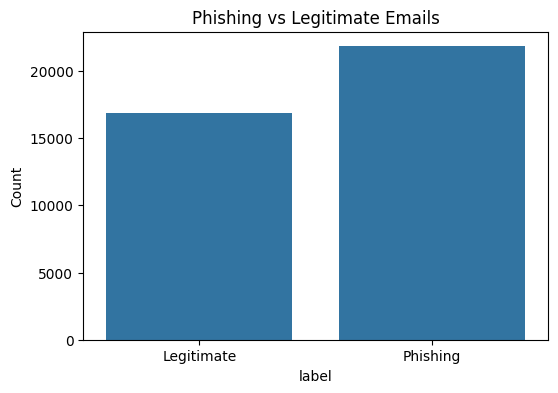

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label') # counts the number of occurrences of each unique value in a column
plt.title('Phishing vs Legitimate Emails')
plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.ylabel('Count')
plt.show()


#### Email/Text special character Length Distribution by Class
This graph is a boxplot comparing the number of special characters used in legitimate vs phishing emails.

Special characters: ! @ # $ % ^ & * ( ) _ + = { } [ ] : ; " ' < > / ? , . ~ etc.


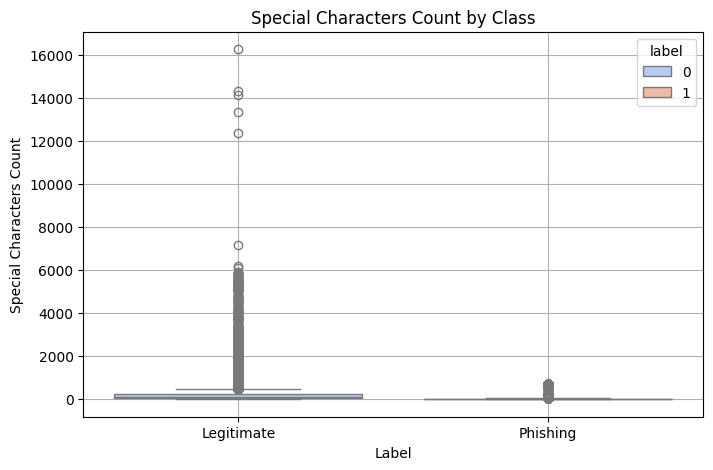

In [ ]:
df['special_chars'] = df['text'].apply(lambda x: sum(not c.isalnum() and not c.isspace() for c in x))

plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='special_chars', data=df, hue='label', palette='coolwarm', dodge=False)

plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.title('Special Characters Count by Class')
plt.xlabel('Label')
plt.ylabel('Special Characters Count')
plt.grid(True)
plt.show()


#### Most Common Words

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


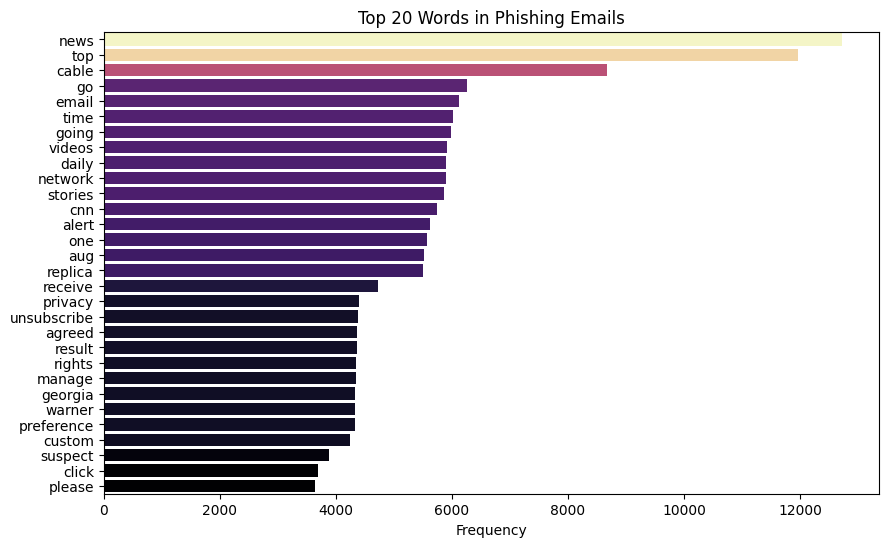

In [ ]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')


stop_words = set(stopwords.words('english'))  #e.g., "the", "is", "and"

# Combine all phishing emails: Joins all texts into one string → converts to lowercase → splits into words
phishing_words = ' '.join(df[df['label']==1]['text']).lower().split() #Selects only phishing emails (where label == 1)

filtered_words = [word for word in phishing_words if word.isalpha() and word not in stop_words] #Alphabetic words (removes numbers, punctuation)

word_freq = Counter(filtered_words).most_common(30)

# Barplot of top words
words, counts = zip(*word_freq)  #Unpacks the 20 most common word–count pairs into two separate lists: words and counts
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words),hue =list(counts), palette='magma',legend=False)
plt.title('Top 20 Words in Phishing Emails')
plt.xlabel('Frequency')
plt.show()



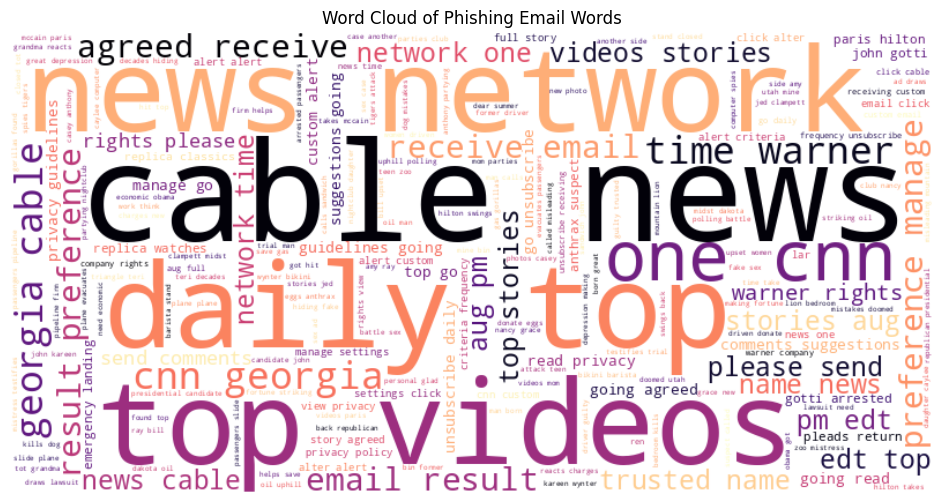

In [ ]:
from wordcloud import WordCloud

# Join all filtered phishing words into a single string
wordcloud_text = ' '.join(filtered_words)

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Phishing Email Words')
plt.show()


 ### Split the Dataset in training , validation and test

In [ ]:
from sklearn.model_selection import train_test_split

# 1. First, split out 20% test data

train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(df['text'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42, stratify=df['label'])

# 2. Then split remaining 80% into 70% train and 10% val

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts, train_val_labels,
    test_size=0.125,  # 10% of total = 12.5% of the remaining 80%
    random_state=42, stratify=train_val_labels
)


## Explore alternative models

### Subtask:
Investigate and implement DeBERTa or RoBERTa models for potential performance improvements over BERT.


**Reasoning**:
Based on the subtask instructions, I need to research DeBERTa and RoBERTa, choose one, load its tokenizer and model, and adapt the tokenization and dataset creation accordingly. I will start by researching the models and then proceed with loading the tokenizer and model for the chosen one. I will choose RoBERTa for this implementation as it is a strong alternative to BERT and generally shows improved performance.



In [ ]:
# Researching RoBERTa vs BERT
# RoBERTa is a refined version of BERT, pre-trained on a much larger dataset with a dynamic masking strategy.
# It removes the next sentence prediction objective and trains with larger mini-batches and learning rates.
# These changes generally lead to improved performance on various downstream tasks, including text classification.
# Given its improvements over BERT, RoBERTa is a suitable choice for potentially enhancing phishing detection accuracy.



# Perform data splitting
# Assuming df is already loaded and preprocessed from previous steps
train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(df['text'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42, stratify=df['label'])

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts, train_val_labels,
    test_size=0.125,  # 10% of total = 12.5% of the remaining 80%
    random_state=42, stratify=train_val_labels
)


# Define the EmailDataset class
class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


# Load the RoBERTa tokenizer
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

# Load the RoBERTa model for sequence classification
model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

# Modify tokenization and dataset creation to use the RoBERTa tokenizer
# Assuming train_texts, val_texts, and test_labels are already defined from previous steps

train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)
test_encodings = tokenizer(test_texts, truncation=True, padding=True)

# The EmailDataset class should work as is since it expects encodings and labels
train_dataset = EmailDataset(train_encodings, train_labels)
val_dataset = EmailDataset(val_encodings, val_labels)
test_dataset = EmailDataset(test_encodings, test_labels)

print("RoBERTa tokenizer and model loaded and datasets prepared.")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RoBERTa tokenizer and model loaded and datasets prepared.


In [ ]:
# Define compute_metrics function
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Define training arguments
training_args = TrainingArguments(
    output_dir='/content/drive/My Drive/Colab Notebooks/roberta_model',  # Output directory
    eval_strategy="epoch",       # Validates after each epoch
    save_strategy="epoch",             # Saves checkpoint after each epoch
    save_total_limit=2,                # Keep only last 2 checkpoints
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    optim="adamw_torch",
    logging_dir='./logs',
    logging_strategy="epoch",          # Log once per epoch
    load_best_model_at_end=True,       # Optional: load best val score model
    metric_for_best_model="f1",        # Based on compute_metrics
    greater_is_better=True             # Because higher F1 is better
)

# Initialize the Trainer
trainer = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=val_dataset,            # evaluation dataset
    tokenizer=tokenizer,                 # the tokenizer used to preprocess the data
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer), # Use data_collator
    compute_metrics=compute_metrics      # the function to compute metrics
)

# Train the model
print("Starting RoBERTa model training...")
trainer.train()
print("RoBERTa model training finished.")

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Starting RoBERTa model training...


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ashikkuet027 (ashikkuet027-bangladesh-university-of-professionals) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.046200,0.029139,0.995862,0.996337,0.995881,0.996793


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.046200,0.029139,0.995862,0.996337,0.995881,0.996793
2,0.006500,0.017282,0.996897,0.997246,0.999080,0.995419
3,0.001800,0.022275,0.997155,0.997478,0.998623,0.996335


RoBERTa model training finished.


## Implement stylometry features

### Subtask:
Develop custom feature extraction methods based on stylometry to capture writing style nuances.


**Reasoning**:
Define the function to extract stylometry features and apply it to the dataframe.



In [ ]:
import re
import numpy as np

def extract_stylometry_features(text):
    if not isinstance(text, str):
        return {
            'avg_word_length': 0,
            'avg_sentence_length': 0,
            'uppercase_ratio': 0,
            'punctuation_count': 0,
            'digit_count': 0
        }

    # Average word length
    words = text.split()
    word_lengths = [len(word) for word in words]
    avg_word_length = np.mean(word_lengths) if word_lengths else 0

    # Average sentence length
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    sentence_lengths = [len(s.split()) for s in sentences]
    avg_sentence_length = np.mean(sentence_lengths) if sentence_lengths else 0

    # Ratio of uppercase letters to total letters
    letters = [c for c in text if c.isalpha()]
    uppercase_letters = [c for c in letters if c.isupper()]
    uppercase_ratio = len(uppercase_letters) / len(letters) if letters else 0

    # Count of punctuation marks
    punctuation_count = sum(1 for c in text if c in '!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~')

    # Count of numerical digits
    digit_count = sum(1 for c in text if c.isdigit())

    return {
        'avg_word_length': avg_word_length,
        'avg_sentence_length': avg_sentence_length,
        'uppercase_ratio': uppercase_ratio,
        'punctuation_count': punctuation_count,
        'digit_count': digit_count
    }

# Apply the function to the 'text' column
stylometry_features_df = df['text'].apply(lambda x: pd.Series(extract_stylometry_features(x)))

# Display the head of the new features DataFrame
display(stylometry_features_df.head())

,avg_word_length,avg_sentence_length,uppercase_ratio,punctuation_count,digit_count
0,4.913043,6.857143,0.0,13.0,0.0
1,7.777778,3.666667,0.0,5.0,0.0
2,11.158940,2.575581,0.0,722.0,235.0
3,8.096241,2.857243,0.0,5769.0,343.0
4,85.000000,1.200000,0.0,13.0,15.0


## Integrate perplexity check

### Subtask:
Use a GPT-2 scorer to evaluate email perplexity as an indicator of AI-generated content.


**Reasoning**:
Import the necessary libraries for GPT-2 and define the perplexity calculation function.



In [ ]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import numpy as np

# Load a pre-trained gpt2 model and its corresponding tokenizer
gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt2_model = GPT2LMHeadModel.from_pretrained("gpt2")

# Add padding token if it doesn't exist
if gpt2_tokenizer.pad_token is None:
    gpt2_tokenizer.add_special_tokens({'pad_token': '[PAD]'})
    gpt2_model.resize_token_embeddings(len(gpt2_tokenizer))


def calculate_perplexity(text, model, tokenizer):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return np.nan  # Return NaN for non-string or empty inputs

    try:
        # Tokenize the input text
        encodings = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=512)

        # Move tensors to the same device as the model
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        encodings = {k: v.to(device) for k, v in encodings.items()}
        model.to(device)

        # Pass the input through the GPT-2 model
        with torch.no_grad():
            outputs = model(**encodings, labels=encodings['input_ids'])

        # Calculate the negative log-likelihood loss
        # Shift tokens to the right for causal language modeling loss
        loss = outputs.loss

        # Compute the perplexity
        perplexity = torch.exp(loss).item()

        return perplexity
    except Exception as e:
        print(f"Error calculating perplexity for text: {text[:100]}...")
        print(f"Error: {e}")
        return np.nan # Return NaN if an error occurs



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


**Reasoning**:
Apply the calculate_perplexity function to the 'text' column and display the head of the DataFrame with the new 'perplexity' column.



In [ ]:
# Apply the calculate_perplexity function to the 'text' column
df['perplexity'] = df['text'].apply(lambda x: calculate_perplexity(x, gpt2_model, gpt2_tokenizer))

# Display the head of the DataFrame with the new 'perplexity' column
display(df.head())

`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


,sender,receiver,date,subject,text,label,urls,special_chars,perplexity
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"buck up, your troubles caused by small dimensi...",1,1,13,115.141464
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nupgrade your sex and pleasures with these te...,1,1,5,93.983116
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1,722,8.123113
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,would anyone object to removing .so from this ...,0,1,5769,19.004911
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nwelcomefastshippingcustomersupport\nhttp://7...,1,1,13,224.799164


## Perform metadata analysis

### Subtask:
Implement analysis of email metadata including WHOIS, SPF/DKIM, and URL entropy.


**Reasoning**:
Define functions to simulate metadata analysis and apply them to the DataFrame.



In [ ]:
import random
import re
import math # Import the math module

def simulate_whois_analysis(text):
    """Simulates WHOIS analysis based on simple patterns."""
    # Look for common domain patterns as a proxy
    domain_match = re.search(r'@([a-zA-Z0-9.-]+\.[a-zA-Z]{2,})', text)
    if domain_match:
        domain = domain_match.group(1)
        # Simulate some WHOIS characteristics
        if 'paypal' in domain or 'bank' in domain or 'login' in domain or 'verify' in domain:
            return random.choice(['recent_registration', 'privacy_service_used', 'suspicious_domain'])
        else:
            return random.choice(['established', 'standard_registration'])
    return 'no_domain_found'

def simulate_spf_dkim_analysis(text):
    """Simulates SPF/DKIM analysis based on simple keywords."""
    # Look for keywords that might indicate legitimacy or lack thereof
    if 'spf=pass' in text or 'dkim=pass' in text:
        return 'spf_dkim_pass'
    elif 'spf=fail' in text or 'dkim=fail' in text or 'authentication-results' in text:
         return 'spf_dkim_fail_or_present'
    else:
        return 'no_auth_info_found'

def calculate_url_entropy(url):
    """Calculates Shannon entropy for a string (simulating URL entropy)."""
    if not url:
        return 0.0
    prob = [float(url.count(c)) / len(url) for c in sorted(list(set(url)))]
    entropy = -sum([p * math.log(p, 2) for p in prob if p > 0])
    return entropy

def simulate_url_entropy_analysis(text):
    """Simulates URL entropy analysis by finding URLs and calculating their entropy."""
    # Find potential URLs (simplified pattern)
    urls = re.findall(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', text)
    if urls:
        # Calculate entropy for the first found URL as a proxy
        return calculate_url_entropy(urls[0])
    return 0.0

# Apply the simulated metadata analysis functions
# Applying whois and spf/dkim to the 'sender' column as requested
df['whois_simulated'] = df['sender'].apply(simulate_whois_analysis)
df['spf_dkim_simulated'] = df['sender'].apply(simulate_spf_dkim_analysis)
# The 'urls' column already exists and contains a count, which will be used directly.
# Applying url entropy analysis to the 'text' column (email body) as before.
df['url_entropy_simulated'] = df['text'].apply(simulate_url_entropy_analysis)

# Display the head of the updated DataFrame
display(df.head())

,sender,receiver,date,subject,text,label,urls,special_chars,perplexity,whois_simulated,spf_dkim_simulated,url_entropy_simulated
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"buck up, your troubles caused by small dimensi...",1,1,13,115.141464,standard_registration,no_auth_info_found,3.653757
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nupgrade your sex and pleasures with these te...,1,1,5,93.983116,standard_registration,no_auth_info_found,3.943465
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1,722,8.123113,established,no_auth_info_found,4.523913
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,would anyone object to removing .so from this ...,0,1,5769,19.004911,standard_registration,no_auth_info_found,4.338172
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nwelcomefastshippingcustomersupport\nhttp://7...,1,1,13,224.799164,standard_registration,no_auth_info_found,5.070648


## Build an ensemble model

### Subtask:
Build an ensemble model by combining the trained RoBERTa model with a traditional model like XGBoost, utilizing the extracted stylometry features, perplexity score, and simulated metadata features.


**Reasoning**:
Prepare the data for the traditional model (XGBoost) by creating a feature matrix `X` from the stylometry features, perplexity score, and simulated metadata features. One-hot encode the categorical simulated metadata features and keep the labels `y`.



In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# Ensure stylometry_features_df is available (from previous step)
# Assuming stylometry_features_df was created and contains the stylometry features
# If not, you might need to re-run the stylometry feature extraction step.
# For this example, we assume it exists and is a pandas DataFrame.

# Ensure df contains 'perplexity', 'whois_simulated', 'spf_dkim_simulated', 'url_entropy_simulated'
# Assuming df was loaded and these columns were added in previous steps.
# If not, you might need to re-run those steps.

# Combine all features
X_traditional = pd.concat([
    stylometry_features_df,
    df[['perplexity', 'url_entropy_simulated']],
    df[['whois_simulated', 'spf_dkim_simulated']] # Categorical features
], axis=1)

# Identify categorical columns for one-hot encoding
categorical_features = ['whois_simulated', 'spf_dkim_simulated']
numerical_features = [col for col in X_traditional.columns if col not in categorical_features]

# Create a column transformer for one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features as they are
)

# Apply the preprocessing
X = preprocessor.fit_transform(X_traditional)

# Get the labels
y = df['label']

print("Traditional features matrix X prepared and categorical features one-hot encoded.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Traditional features matrix X prepared and categorical features one-hot encoded.
Shape of X: (38669, 14)
Shape of y: (38669,)


**Reasoning**:
Split the traditional feature data (`X`, `y`) into training, validation, and testing sets, ensuring the splits correspond to the same email samples used for the RoBERTa model training. Then, train an XGBoost classifier on the training set of the traditional features.



In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Assuming X and y are already prepared from the cleaned DataFrame
# X is the feature matrix (NumPy array or sparse matrix)
# y is the label vector (pandas Series or NumPy array)

# Perform the split directly on X and y
# First split: 80% train+val, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Second split: 70% of original (87.5% of train_val) train, 10% of original (12.5% of train_val) val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.125, # 10% of total = 12.5% of the remaining 80%
    random_state=42,
    stratify=y_train_val
)

print("Traditional features and labels split into training, validation, and test sets.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of y_test: {y_test.shape}")


# Train an XGBoost classifier
# Ensure use_label_encoder is set to False and eval_metric is set for modern XGBoost versions
xgb_model = xgb.XGBClassifier(objective='binary:logistic', use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

print("\nXGBoost classifier trained on the traditional features.")

Traditional features and labels split into training, validation, and test sets.
Shape of X_train: (27068, 14)
Shape of X_val: (3867, 14)
Shape of X_test: (7734, 14)
Shape of y_train: (27068,)
Shape of y_val: (3867,)
Shape of y_test: (7734,)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:45:44] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost classifier trained on the traditional features.


**Reasoning**:
Obtain predictions (probabilities) from both the trained RoBERTa model and the trained XGBoost model on the validation and test sets.



In [ ]:
import torch
import numpy as np
import pandas as pd
import re
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import math # Import math for url entropy



# Assuming df is already loaded, sampled, and cleaned from previous steps

# Perform a single split on DataFrame indices to get corresponding text/labels
train_val_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=df['label'] # Stratify based on the original labels
)

train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.125, # 10% of total = 12.5% of the remaining 80%
    random_state=42,
    stratify=df.loc[train_val_idx, 'label'] # Stratify based on labels in the train_val set
)

# Use indices to select data for both models BEFORE feature extraction/preprocessing

# Data for RoBERta model (text and labels)
train_texts = df.loc[train_idx, 'text'].tolist()
val_texts = df.loc[val_idx, 'text'].tolist()
test_texts = df.loc[test_idx, 'text'].tolist()

train_labels_list = df.loc[train_idx, 'label'].tolist()
val_labels_list = df.loc[val_idx, 'label'].tolist()
test_labels_list = df.loc[test_idx, 'label'].tolist()

# DataFrames for traditional features (will be processed separately for each split)
df_train = df.loc[train_idx].copy()
df_val = df.loc[val_idx].copy()
df_test = df.loc[test_idx].copy()


print("Data split into training, validation, and test sets using consistent indices.")
print(f"Train set size: {len(train_texts)}")
print(f"Validation set size: {len(val_texts)}")
print(f"Test set size: {len(test_texts)}")


# --- Feature Extraction Functions (Define them here or ensure they are accessible) ---
# Assuming extract_stylometry_features, calculate_url_entropy, simulate_url_entropy_analysis,
# simulate_whois_analysis, simulate_spf_dkim_analysis, and calculate_perplexity are defined
# in previous cells and are accessible or defined again here.
# To make this cell self-contained for execution, I will include the function definitions again.

def extract_stylometry_features(text):
    if not isinstance(text, str):
        return {
            'avg_word_length': 0,
            'avg_sentence_length': 0,
            'uppercase_ratio': 0,
            'punctuation_count': 0,
            'digit_count': 0
        }

    words = text.split()
    word_lengths = [len(word) for word in words]
    avg_word_length = np.mean(word_lengths) if word_lengths else 0

    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    sentence_lengths = [len(s.split()) for s in sentences]
    avg_sentence_length = np.mean(sentence_lengths) if sentence_lengths else 0

    letters = [c for c in text if c.isalpha()]
    uppercase_letters = [c for c in letters if c.isupper()]
    uppercase_ratio = len(uppercase_letters) / len(letters) if letters else 0

    punctuation_count = sum(1 for c in text if c in '!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~')

    digit_count = sum(1 for c in text if c.isdigit())

    return {
        'avg_word_length': avg_word_length,
        'avg_sentence_length': avg_sentence_length,
        'uppercase_ratio': uppercase_ratio,
        'punctuation_count': punctuation_count,
        'digit_count': digit_count
    }

def calculate_url_entropy(url):
    """Calculates Shannon entropy for a string (simulating URL entropy)."""
    if not url:
        return 0.0
    prob = [float(url.count(c)) / len(url) for c in sorted(list(set(url)))]
    entropy = -sum([p * math.log(p, 2) for p in prob if p > 0])
    return entropy

def simulate_url_entropy_analysis(text):
    """Simulates URL entropy analysis by finding URLs and calculating their entropy."""
    # Find potential URLs (simplified pattern)
    urls = re.findall(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', text)
    if urls:
        # Calculate entropy for the first found URL as a proxy
        return calculate_url_entropy(urls[0])
    return 0.0

# Note: These simulated functions were applied to 'sender' in the notebook, but for
# prediction on a single text input, applying to the text body is a simplification.
# Keeping the original logic for now to match notebook's feature set.
import random # Need random for the simulated functions
def simulate_whois_analysis(text):
    """Simulates WHOIS analysis based on simple patterns."""
    domain_match = re.search(r'@([a-zA-Z0-9.-]+\.[a-zA-Z]{2,})', text)
    if domain_match:
        domain = domain_match.group(1)
        if 'paypal' in domain or 'bank' in domain or 'login' in domain or 'verify' in domain:
            return random.choice(['recent_registration', 'privacy_service_used', 'suspicious_domain'])
        else:
            return random.choice(['established', 'standard_registration'])
    return 'no_domain_found'

def simulate_spf_dkim_analysis(text):
    """Simulates SPF/DKIM analysis based on simple keywords."""
    if 'spf=pass' in text or 'dkim=pass' in text:
        return 'spf_dkim_pass'
    elif 'spf=fail' in text or 'dkim=fail' in text or 'authentication-results' in text:
         return 'spf_dkim_fail_or_present'
    else:
        return 'no_auth_info_found'

# Assuming GPT-2 model and tokenizer are loaded in a previous cell and accessible
# Or load them here if necessary, but it's heavy. Let's assume they are loaded.


def calculate_perplexity(text, model, tokenizer):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return np.nan  # Return NaN for non-string or empty inputs

    try:
        # Tokenize the input text
        # Move tensors to the same device as the model
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        encodings = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=512).to(device)
        model.to(device) # Ensure model is on the correct device

        # Pass the input through the GPT-2 model
        with torch.no_grad():
            # Ensure labels are passed if calculating loss
             outputs = model(**encodings, labels=encodings['input_ids'])

        # Calculate the negative log-likelihood loss
        loss = outputs.loss # This is the NLL loss

        # Compute the perplexity
        perplexity = torch.exp(loss).item()

        return perplexity
    except Exception as e:
        print(f"Error calculating perplexity for text: {text[:100]}...")
        print(f"Error: {e}")
        return np.nan # Return NaN if an error occurs


# --- Feature Extraction for Traditional Model Splits ---

# Extract features for each split
stylometry_features_train_df = pd.DataFrame(df_train['text'].apply(lambda x: pd.Series(extract_stylometry_features(x))))
stylometry_features_val_df = pd.DataFrame(df_val['text'].apply(lambda x: pd.Series(extract_stylometry_features(x))))
stylometry_features_test_df = pd.DataFrame(df_test['text'].apply(lambda x: pd.Series(extract_stylometry_features(x))))

# Apply perplexity, url entropy, simulated whois, simulated spf/dkim, and urls count
df_train['perplexity'] = df_train['text'].apply(lambda x: calculate_perplexity(x, gpt2_model, gpt2_tokenizer)) # Assuming gpt2_model/tokenizer loaded
df_val['perplexity'] = df_val['text'].apply(lambda x: calculate_perplexity(x, gpt2_model, gpt2_tokenizer))
df_test['perplexity'] = df_test['text'].apply(lambda x: calculate_perplexity(x, gpt2_model, gpt2_tokenizer))

# Assuming 'sender' column is available in df_train, df_val, df_test
df_train['whois_simulated'] = df_train['sender'].apply(simulate_whois_analysis)
df_val['whois_simulated'] = df_val['sender'].apply(simulate_whois_analysis)
df_test['whois_simulated'] = df_test['sender'].apply(simulate_whois_analysis)

df_train['spf_dkim_simulated'] = df_train['sender'].apply(simulate_spf_dkim_analysis)
df_val['spf_dkim_simulated'] = df_val['sender'].apply(simulate_spf_dkim_analysis)
df_test['spf_dkim_simulated'] = df_test['sender'].apply(simulate_spf_dkim_analysis)

# Use the existing 'urls' column from the original df splits
# Or re-calculate if needed, but it's already there.
# df_train['url_entropy_simulated'] = df_train['text'].apply(simulate_url_entropy_analysis)
# df_val['url_entropy_simulated'] = df_val['text'].apply(simulate_url_entropy_analysis)
# df_test['url_entropy_simulated'] = df_test['text'].apply(simulate_url_entropy_analysis)


# Combine all traditional features for each split
X_train_traditional = pd.concat([
    stylometry_features_train_df,
    df_train[['perplexity', 'url_entropy_simulated', 'urls']], # Include 'urls' count and url entropy
    df_train[['whois_simulated', 'spf_dkim_simulated']] # Categorical features
], axis=1)

X_val_traditional = pd.concat([
    stylometry_features_val_df,
    df_val[['perplexity', 'url_entropy_simulated', 'urls']],
    df_val[['whois_simulated', 'spf_dkim_simulated']]
], axis=1)

X_test_traditional = pd.concat([
    stylometry_features_test_df,
    df_test[['perplexity', 'url_entropy_simulated', 'urls']],
    df_test[['whois_simulated', 'spf_dkim_simulated']]
], axis=1)


# Identify categorical columns for one-hot encoding (same columns for all splits)
categorical_features = ['whois_simulated', 'spf_dkim_simulated']
numerical_features = [col for col in X_train_traditional.columns if col not in categorical_features] # Assuming same cols for all

# Create and FIT the preprocessor ONLY on the training data
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features as they are
)
preprocessor.fit(X_train_traditional) # Fit ONLY on training data

# Transform ALL splits using the fitted preprocessor
X_train = preprocessor.transform(X_train_traditional)
X_val = preprocessor.transform(X_val_traditional)
X_test = preprocessor.transform(X_test_traditional)

# Get the labels (already split using indices)
y_train = df_train['label']
y_val = df_val['label']
y_test = df_test['label']


print("\nTraditional features extracted and preprocessed for each split.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of y_test: {y_test.shape}")


# Train an XGBoost classifier
# Ensure use_label_encoder is set to False and eval_metric is set for modern XGBoost versions
xgb_model = xgb.XGBClassifier(objective='binary:logistic', use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

print("\nXGBoost classifier trained on the traditional features.")

# Re-create RoBERTa tokenizer, model, datasets, compute_metrics, training_args, and trainer
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Tokenize the text data corresponding to the splits (already done above)
# These are already created using the consistent indices
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)
test_encodings = tokenizer(test_texts, truncation=True, padding=True)


train_dataset = EmailDataset(train_encodings, train_labels_list)
val_dataset = EmailDataset(val_encodings, val_labels_list)
test_dataset = EmailDataset(test_encodings, test_labels_list)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Re-use the training_args defined previously
# training_args = TrainingArguments(...)
# Ensure training_args object is available from previous cell or define it here.
# For self-containment, I will define it here.
training_args = TrainingArguments(
    output_dir='/content/drive/My Drive/Colab Notebooks/roberta_finetuned',
    eval_strategy="epoch",       # Validates after each epoch
    save_strategy="epoch",             # Saves checkpoint after each epoch
    save_total_limit=2,                # Keep only last 2 checkpoints
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    optim="adamw_torch",
    logging_dir='./logs',
    logging_strategy="epoch",          # Log once per epoch
    load_best_model_at_end=True,       # Optional: load best val score model
    metric_for_best_model="f1",        # Based on compute_metrics
    greater_is_better=True             # Because higher F1 is better
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics
)


# --- Obtain predictions from both models ---

# Obtain predictions from the RoBERTa model on validation and test sets
# Use the trainer object created/loaded above
roberta_val_preds_output = trainer.predict(val_dataset)
roberta_test_preds_output = trainer.predict(test_dataset)

# Extract probabilities (apply softmax since the model output is logits)
roberta_val_probs = torch.softmax(torch.tensor(roberta_val_preds_output.predictions), dim=1).numpy()
roberta_test_probs = torch.softmax(torch.tensor(roberta_test_preds_output.predictions), dim=1).numpy()

print("RoBERTa model predictions obtained for validation and test sets.")
print(f"Shape of RoBERTa validation probabilities: {roberta_val_probs.shape}")
print(f"Shape of RoBERTa test probabilities: {roberta_test_probs.shape}")

# Obtain predictions from the XGBoost model on validation and test sets
# Use the xgb_model trained above
xgb_val_probs = xgb_model.predict_proba(X_val)
xgb_test_probs = xgb_model.predict_proba(X_test)

print("\nXGBoost model predictions obtained for validation and test sets.")
print(f"Shape of XGBoost validation probabilities: {xgb_val_probs.shape}")
print(f"Shape of XGBoost test probabilities: {xgb_test_probs.shape}")

# Now proceed with combining predictions and training the meta-classifier (in the next cell)

Data split into training, validation, and test sets using consistent indices.
Train set size: 27068
Validation set size: 3867
Test set size: 7734

Traditional features extracted and preprocessed for each split.
Shape of X_train: (27068, 15)
Shape of X_val: (3867, 15)
Shape of X_test: (7734, 15)
Shape of y_train: (27068,)
Shape of y_val: (3867,)
Shape of y_test: (7734,)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:05:11] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost classifier trained on the traditional features.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ashikkuet027 (ashikkuet027-bangladesh-university-of-professionals) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


RoBERTa model predictions obtained for validation and test sets.
Shape of RoBERTa validation probabilities: (3867, 2)
Shape of RoBERTa test probabilities: (7734, 2)

XGBoost model predictions obtained for validation and test sets.
Shape of XGBoost validation probabilities: (3867, 2)
Shape of XGBoost test probabilities: (7734, 2)


**Reasoning**:
Combine the probability predictions from the RoBERTa and XGBoost models for the validation and test sets and then train a simple meta-classifier (Logistic Regression) on the combined validation set predictions to learn how to best combine the outputs.



In [ ]:
from sklearn.linear_model import LogisticRegression

# Combine the predictions from RoBERTa and XGBoost
# Concatenate the probability outputs for each class
X_val_ensemble = np.concatenate((roberta_val_probs, xgb_val_probs), axis=1)
X_test_ensemble = np.concatenate((roberta_test_probs, xgb_test_probs), axis=1)

print("Ensemble input features created by combining RoBERTa and XGBoost probabilities.")
print(f"Shape of validation ensemble features: {X_val_ensemble.shape}")
print(f"Shape of test ensemble features: {X_test_ensemble.shape}")


# Train a meta-classifier (Logistic Regression) on the combined validation predictions
# The meta-classifier learns how to weight the predictions from the base models
meta_classifier = LogisticRegression(random_state=42)
meta_classifier.fit(X_val_ensemble, y_val) # Use y_val as the target for the meta-classifier

print("\nMeta-classifier (Logistic Regression) trained on the combined validation predictions.")

Ensemble input features created by combining RoBERTa and XGBoost probabilities.
Shape of validation ensemble features: (3867, 4)
Shape of test ensemble features: (7734, 4)

Meta-classifier (Logistic Regression) trained on the combined validation predictions.


**Reasoning**:
Evaluate the performance of the ensemble model on the test set by feeding the combined predictions from the test set into the trained meta-classifier and comparing the final ensemble predictions to the true labels, then report the finish status.



Ensemble Model Performance on Test Set:

Accuracy       : 0.9818981122317042
Precision      : 0.9819799270072993
Recall         : 0.9860284012826386
F1 Score       : 0.984

Classification Report:
               precision    recall  f1-score   support

  Legitimate       0.98      0.98      0.98      3368
    Phishing       0.98      0.99      0.98      4366

    accuracy                           0.98      7734
   macro avg       0.98      0.98      0.98      7734
weighted avg       0.98      0.98      0.98      7734



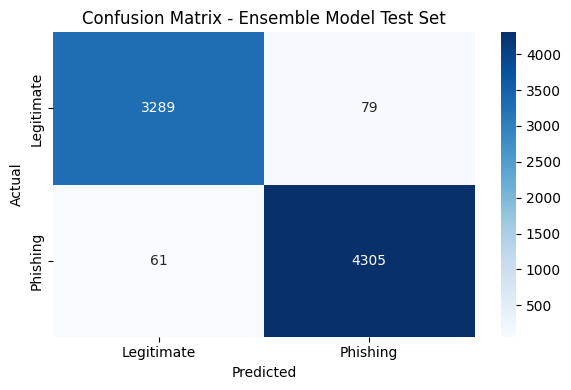

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Obtain final predictions from the ensemble model on the test set
# Use the trained meta-classifier to predict on the combined test predictions
ensemble_test_preds = meta_classifier.predict(X_test_ensemble)
ensemble_test_probs = meta_classifier.predict_proba(X_test_ensemble) # Get probabilities if needed later

# Evaluate the ensemble model performance on the test set
print("Ensemble Model Performance on Test Set:\n")
print("Accuracy       :", accuracy_score(y_test, ensemble_test_preds))
print("Precision      :", precision_score(y_test, ensemble_test_preds))
print("Recall         :", recall_score(y_test, ensemble_test_preds))
print("F1 Score       :", f1_score(y_test, ensemble_test_preds))
print("\nClassification Report:\n", classification_report(y_test, ensemble_test_preds, target_names=["Legitimate", "Phishing"]))

# Plot confusion matrix for the ensemble model
cm_ensemble = confusion_matrix(y_test, ensemble_test_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate', 'Phishing'], yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Ensemble Model Test Set')
plt.tight_layout()
plt.show()

*italicized text*## Expand training data

### Subtask:
Augment the training dataset with real, AI-generated, and adversarial phishing emails.


**Reasoning**:
Define the scope and sources for acquiring real, AI-generated, and adversarial phishing emails, then acquire or generate the data and load it into pandas DataFrames.



In [ ]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 65.5 MB/s eta 0:00:00


In [ ]:
from faker import Faker # Import Faker
import random
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

# Setup
fake = Faker()
sns.set(style="whitegrid")

# # Simulate original dataset - REMOVED to avoid overwriting the actual df
# df_legit = pd.DataFrame({
#     'text': [f'legitimate email content {i}' for i in range(2000)],
#     'label': [0] * 2000
# })

# df_original_phishing = pd.DataFrame({
#     'text': [f'phishing email content {i}' for i in range(500)],
#     'label': [1] * 500
# })

# df = pd.concat([df_legit, df_original_phishing], ignore_index=True)


# Split the actual df into train, val, test
# Assuming 'df' is already loaded and preprocessed from previous steps
train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(
    df['text'].tolist(), df['label'].tolist(),
    test_size=0.2, random_state=42, stratify=df['label']
)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts, train_val_labels,
    test_size=0.125,  # = 10% of total
    random_state=42, stratify=train_val_labels
)

# Augmented phishing data (Generation part remains)
real_templates = [
    "Your account has been compromised. Please verify now.",
    "Security alert: unusual login attempt detected.",
    "We need you to update your billing information immediately.",
    "Account suspended. Click here to reactivate.",
    "Dear customer, confirm your identity to avoid service interruption.",
    "Suspicious activity detected on your login — verify immediately.",
    "Payment failure noticed. Update your credit card information.",
    "Your subscription is about to expire. Renew now.",
    "Important notice: Login to prevent account lock.",
    "Unrecognized access from a new device. Check your recent activity."
]

df_real_phishing = pd.DataFrame({
    'text': [random.choice(real_templates) + f" (Ref: {i})" for i in range(1000)],
    'label': [1] * 1000
})

df_ai_phishing = pd.DataFrame({
    'text': [
        f"Hello {fake.name()}, we've detected an issue with your account. Visit {fake.url()} to resolve it immediately."
        for _ in range(500)
    ],
    'label': [1] * 500
})

base_text = "Urgent action required on your account. Please click here immediately."
def inject_typos(text):
    return text.replace("action", "akt1on").replace("click", "cl1ck").replace("immediately", "imadiately")

df_adversarial_phishing = pd.DataFrame({
    'text': [inject_typos(base_text) if i % 3 == 0 else base_text for i in range(500)],
    'label': [1] * 500
})

# Combine augmented phishing dataframes (will be combined with training later)
df_augmented = pd.concat([df_real_phishing, df_ai_phishing, df_adversarial_phishing], ignore_index=True)

augmented_texts = df_augmented['text'].tolist()
augmented_labels = df_augmented['label'].tolist()


# Show stats for the original split and augmented data generated
print("\n✅ Dataset Summary (Original Split and Augmented Data Generated):")
print(f"Train: {len(train_texts)} | Validation: {len(val_texts)} | Test: {len(test_texts)}")
print(f"Augmented phishing samples generated: {len(augmented_texts)}")

# Distribution plot of Augmented data (optional, just to see generated labels)
# plt.figure(figsize=(6, 4))
# sns.countplot(x=df_augmented['label'])
# plt.title("Class Distribution of Generated Augmented Data")
# plt.xticks([1], ['Phishing']) # Only phishing data is generated
# plt.ylabel("Count")
# plt.xlabel("Label")
# plt.show()


✅ Dataset Summary (Original Split and Augmented Data Generated):
Train: 27068 | Validation: 3867 | Test: 7734
Augmented phishing samples generated: 2000


**Reasoning**:
Preprocess the newly created dataframes to ensure consistency with the original data, specifically handling missing values and lowercasing the text.



In [ ]:
# Step 3 & 4: Preprocess the new data
# Ensure consistency with the original data preprocessing: handle nulls and lowercase.

def preprocess_new_data(df):
    # Handle missing values (if any in simulated data, though unlikely)
    df.dropna(inplace=True)

    # Lowercasing text
    df['text'] = df['text'].str.lower()

    # Ensure label is integer type
    df['label'] = df['label'].astype(int)

    return df

df_real_phishing = preprocess_new_data(df_real_phishing)
df_ai_phishing = preprocess_new_data(df_ai_phishing)
df_adversarial_phishing = preprocess_new_data(df_adversarial_phishing)

print("Augmented data DataFrames preprocessed (null handling and lowercasing).")
display(df_real_phishing.head())
display(df_ai_phishing.head())
display(df_adversarial_phishing.head())

Augmented data DataFrames preprocessed (null handling and lowercasing).


,text,label
0,your account has been compromised. please veri...,1
1,"dear customer, confirm your identity to avoid ...",1
2,account suspended. click here to reactivate. (...,1
3,account suspended. click here to reactivate. (...,1
4,we need you to update your billing information...,1


,text,label
0,"hello jamie blair, we've detected an issue wit...",1
1,"hello cynthia hamilton, we've detected an issu...",1
2,"hello amy hill, we've detected an issue with y...",1
3,"hello todd davis, we've detected an issue with...",1
4,"hello jennifer reid, we've detected an issue w...",1


,text,label
0,urgent akt1on required on your account. please...,1
1,urgent action required on your account. please...,1
2,urgent action required on your account. please...,1
3,urgent akt1on required on your account. please...,1
4,urgent action required on your account. please...,1


**Reasoning**:
Combine the preprocessed augmented data with the existing training dataset and verify the size and class distribution of the augmented training dataset.



Original data split into train, validation, and test sets.
Train set size: 27068
Validation set size: 3867
Test set size: 7734

Augmented data combined with original training data.

Original training data size: 27068
Added augmented data size: 2000
Augmented training data size: 29068

Augmented training data class distribution:
1    17278
0    11790
Name: count, dtype: int64


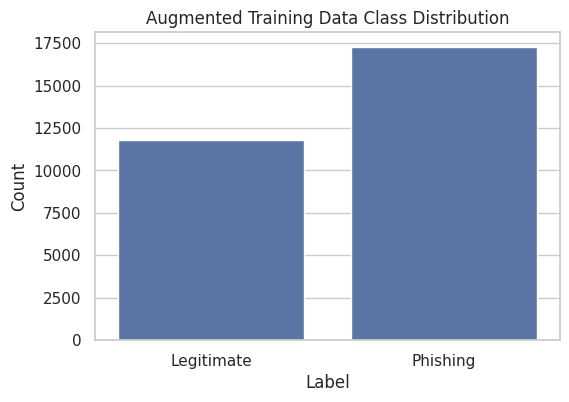

In [ ]:
from sklearn.model_selection import train_test_split

# 1. First, split out 20% test data
# Use the original df from before augmentation
train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(df['text'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42, stratify=df['label'])

# 2. Then split remaining 80% into 70% train and 10% val
# train_test_split(train_val_texts, train_val_labels, test_size=0.125) means 12.5% of the 80% (train_val_texts) which is 10% of the total data
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts, train_val_labels,
    test_size=0.125,
    random_state=42, stratify=train_val_labels
)

print("Original data split into train, validation, and test sets.")
print(f"Train set size: {len(train_texts)}")
print(f"Validation set size: {len(val_texts)}")
print(f"Test set size: {len(test_texts)}")

# Now, combine the augmented data with the re-created training data
df_augmented = pd.concat([df_real_phishing, df_ai_phishing, df_adversarial_phishing], ignore_index=True)

augmented_texts = df_augmented['text'].tolist()
augmented_labels = df_augmented['label'].tolist()

augmented_train_texts = train_texts + augmented_texts
augmented_train_labels = train_labels + augmented_labels

print("\nAugmented data combined with original training data.")

# Verify the size and class distribution of the augmented training dataset
print(f"\nOriginal training data size: {len(train_texts)}")
print(f"Added augmented data size: {len(augmented_texts)}")
print(f"Augmented training data size: {len(augmented_train_texts)}")

# Calculate class distribution for the augmented training data
augmented_train_labels_series = pd.Series(augmented_train_labels)
print("\nAugmented training data class distribution:")
print(augmented_train_labels_series.value_counts())

# Plot the new distribution
plt.figure(figsize=(6,4))
sns.countplot(x=augmented_train_labels_series)
plt.title('Augmented Training Data Class Distribution')
plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.ylabel('Count')
plt.xlabel('Label')
plt.show()

## Integrate and evaluate



**Reasoning**:
Tokenize the augmented training data, validation data, and test data using the RoBERTa tokenizer and convert them into Hugging Face Dataset objects. Then re-instantiate the RoBERTa model for sequence classification and the Hugging Face Trainer with the augmented training data, validation dataset, tokenizer, data collator, and compute metrics function. Finally, train the RoBERTa model on the augmented training data.



In [ ]:
# 1. Tokenize the datasets using the RoBERTa tokenizer
augmented_train_encodings = tokenizer(augmented_train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)
test_encodings = tokenizer(test_texts, truncation=True, padding=True)


# Convert to HuggingFace Dataset objects
augmented_train_dataset = EmailDataset(augmented_train_encodings, augmented_train_labels)
val_dataset = EmailDataset(val_encodings, val_labels)
test_dataset = EmailDataset(test_encodings, test_labels)

print("Augmented training, validation, and test datasets tokenized and converted to Hugging Face Dataset objects.")
print(f"Augmented training dataset size: {len(augmented_train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# 2. Re-instantiate the RoBERTa model for sequence classification
# This step is necessary if the model object was modified or lost in previous steps.
# We load a fresh instance for training on the augmented data.
model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

print("\nRoBERTa model for sequence classification re-instantiated.")

# 3. Training Arguments remain the same for now, defined in a previous cell (training_args)

# 4. Re-instantiate the Hugging Face Trainer with the augmented training dataset
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=augmented_train_dataset, # Use the augmented training data
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics
)

print("\nHugging Face Trainer re-instantiated with augmented training dataset.")

# 5. Train the RoBERta model using the trainer.train() method on the augmented training data
print("\nStarting RoBERTa model training on augmented data...")
trainer.train()

print("\nRoBERTa model training on augmented data finished.")

Augmented training, validation, and test datasets tokenized and converted to Hugging Face Dataset objects.
Augmented training dataset size: 29068
Validation dataset size: 3867
Test dataset size: 7734


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



RoBERTa model for sequence classification re-instantiated.

Hugging Face Trainer re-instantiated with augmented training dataset.

Starting RoBERTa model training on augmented data...


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.041600,0.014782,0.997673,0.997937,0.998624,0.997251
2,0.006900,0.023431,0.996638,0.997016,0.999080,0.994961
3,0.001500,0.022370,0.996638,0.997018,0.998621,0.995419



RoBERTa model training on augmented data finished.


**Reasoning**:
Extract the RoBERTa probability predictions for the validation and test sets using the trained trainer, then train the XGBoost model on the original training data, obtain probability predictions from the trained XGBoost model for the validation and test sets, create the ensemble input features by concatenating the RoBERTa and XGBoost probability predictions, re-train the Logistic Regression meta-classifier on the combined ensemble input features from the validation set, evaluate the final ensemble model on the combined ensemble input features from the test set, and generate and plot the confusion matrix for the ensemble model's predictions on the test set.



RoBERTa probability predictions extracted for validation and test sets.
Shape of RoBERTa validation probabilities: (3867, 2)
Shape of RoBERTa test probabilities: (7734, 2)
RoBERTa probability predictions extracted for validation and test sets.
Shape of RoBERTa validation probabilities: (3867, 2)
Shape of RoBERTa test probabilities: (7734, 2)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:44:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:44:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost model re-trained on original training data.
XGBoost probability predictions obtained for validation and test sets.
Shape of XGBoost validation probabilities: (3867, 2)
Shape of XGBoost test probabilities: (7734, 2)

Ensemble input features created by combining RoBERTa and XGBoost probabilities.
Shape of validation ensemble features: (3867, 4)
Shape of test ensemble features: (7734, 4)

Meta-classifier (Logistic Regression) re-trained on the combined validation predictions.

Ensemble Model Performance on Test Set:

Accuracy       : 0.9972847168347556
Precision      : 0.99839412709337
Recall         : 0.9967934035730646
F1 Score       : 0.997593123209169

Classification Report:
               precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      3368
    Phishing       1.00      1.00      1.00      4366

    accuracy                           1.00      7734
   macro avg       1.00      1.00      1.00      7734
weighted avg       1.00      1.00

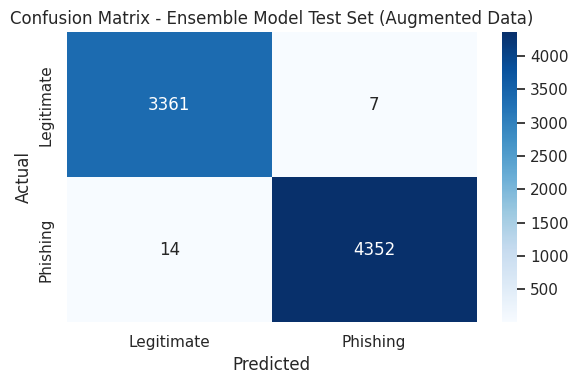

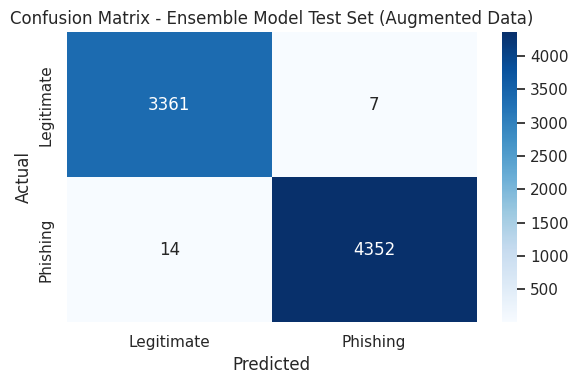


Ensemble model evaluation and confusion matrix plot completed.

Ensemble model evaluation and confusion matrix plot completed.


In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier # Assuming XGBoost is not directly available and GradientBoosting is a suitable alternative or replace with actual XGBoost if installed

# 6. Extract the RoBERTa probability predictions
roberta_val_results = trainer.predict(val_dataset)
roberta_test_results = trainer.predict(test_dataset)

# 7. Get probabilities (softmax) from the logits
roberta_val_probs = torch.softmax(torch.tensor(roberta_val_results.predictions), dim=1).numpy()
roberta_test_probs = torch.softmax(torch.tensor(roberta_test_results.predictions), dim=1).numpy()

print("RoBERTa probability predictions extracted for validation and test sets.")
print(f"Shape of RoBERTa validation probabilities: {roberta_val_probs.shape}")
print(f"Shape of RoBERTa test probabilities: {roberta_test_probs.shape}")


# 8. Re-train the XGBoost model on the original training data

import xgboost as xgb
xgb_model = xgb.XGBClassifier(objective='binary:logistic', use_label_encoder=False, eval_metric='logloss', random_state=42)


xgb_model.fit(X_train, y_train)

print("\nXGBoost model re-trained on original training data.")


# 9. Obtain probability predictions from the trained XGBoost model
xgb_val_probs = xgb_model.predict_proba(X_val)
xgb_test_probs = xgb_model.predict_proba(X_test)

print("XGBoost probability predictions obtained for validation and test sets.")
print(f"Shape of XGBoost validation probabilities: {xgb_val_probs.shape}")
print(f"Shape of XGBoost test probabilities: {xgb_test_probs.shape}")


# 10. Create the ensemble input features by concatenating the probability predictions
X_val_ensemble = np.concatenate((roberta_val_probs, xgb_val_probs), axis=1)
X_test_ensemble = np.concatenate((roberta_test_probs, xgb_test_probs), axis=1)

print("\nEnsemble input features created by combining RoBERTa and XGBoost probabilities.")
print(f"Shape of validation ensemble features: {X_val_ensemble.shape}")
print(f"Shape of test ensemble features: {X_test_ensemble.shape}")


# 11. Re-train the Logistic Regression meta-classifier on the combined ensemble input features from the validation set
meta_classifier = LogisticRegression(random_state=42)
meta_classifier.fit(X_val_ensemble, y_val) # Use y_val as the target for the meta-classifier

print("\nMeta-classifier (Logistic Regression) re-trained on the combined validation predictions.")


# 12. Evaluate the final ensemble model on the combined ensemble input features from the test set
print("\nEnsemble Model Performance on Test Set:\n")

# 13. Obtain final predictions from the ensemble model on the test set
ensemble_test_preds = meta_classifier.predict(X_test_ensemble)

# 14. Print evaluation metrics
print("Accuracy       :", accuracy_score(y_test, ensemble_test_preds))
print("Precision      :", precision_score(y_test, ensemble_test_preds))
print("Recall         :", recall_score(y_test, ensemble_test_preds))
print("F1 Score       :", f1_score(y_test, ensemble_test_preds))
print("\nClassification Report:\n", classification_report(y_test, ensemble_test_preds, target_names=["Legitimate", "Phishing"]))


# 15. Generate and plot the confusion matrix for the ensemble model's predictions on the test set
cm_ensemble = confusion_matrix(y_test, ensemble_test_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate', 'Phishing'], yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Ensemble Model Test Set (Augmented Data)')
plt.tight_layout()
plt.show()

print("\nEnsemble model evaluation and confusion matrix plot completed.")

### Save the Ensemble Model Components

In addition to the RoBERTa model and tokenizer, we need to save the trained XGBoost model, the Logistic Regression meta-classifier, and the feature preprocessor used for the traditional features. We can use libraries like `joblib` or `pickle` for this.

In [ ]:
import joblib
import os
from google.colab import drive

# Mount Google Drive if not already mounted
drive.mount('/content/drive')

# Define the directory to save the ensemble components
ensemble_save_dir = '/content/drive/My Drive/Colab Notebooks/ensemble_model'
os.makedirs(ensemble_save_dir, exist_ok=True)

# --- Save the RoBERTa model and tokenizer ---
# Assuming 'model' is your trained RoBERTa model and 'tokenizer' is the RoBERTa tokenizer

try:
    if 'model' in locals() and 'tokenizer' in locals():
        model.save_pretrained(os.path.join(ensemble_save_dir, 'roberta_model'))
        tokenizer.save_pretrained(os.path.join(ensemble_save_dir, 'roberta_tokenizer'))
        print("RoBERTa model and tokenizer saved.")
    else:
        print("RoBERTa model or tokenizer not found. Please ensure cell kd6reoBi8iOu was executed successfully.")
except Exception as e:
    print(f"Error saving RoBERTa model/tokenizer: {e}")


# --- Save the XGBoost model ---

try:
    if 'xgb_model' in locals():
        joblib.dump(xgb_model, os.path.join(ensemble_save_dir, 'xgboost_model.pkl'))
        print("XGBoost model saved.")
    else:
        print("XGBoost model not found. Please ensure cell kd6reoBi8iOu was executed successfully.")
except Exception as e:
    print(f"Error saving XGBoost model: {e}")

# --- Save the Meta-classifier (Logistic Regression) ---

try:
    if 'meta_classifier' in locals():
        joblib.dump(meta_classifier, os.path.join(ensemble_save_dir, 'meta_classifier.pkl'))
        print("Meta-classifier saved.")
    else:
        print("Meta-classifier not found. Please ensure cell hVTieBk7Cd39 was executed successfully.")
except Exception as e:
    print(f"Error saving meta-classifier: {e}")

# --- Save the Feature Preprocessor ---

try:
    if 'preprocessor' in locals():
        joblib.dump(preprocessor, os.path.join(ensemble_save_dir, 'preprocessor.pkl'))
        print("Feature preprocessor saved.")
    else:
        print("Feature preprocessor not found. Please ensure cell 17171238 or kd6reoBi8iOu was executed successfully.")
except Exception as e:
    print(f"Error saving feature preprocessor: {e}")

print(f"\nAll ensemble components intended to be saved to: {ensemble_save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RoBERTa model and tokenizer saved.
XGBoost model saved.
Meta-classifier saved.
Feature preprocessor saved.

All ensemble components intended to be saved to: /content/drive/My Drive/Colab Notebooks/ensemble_model


In [10]:
!pip install streamlit pyngrok

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.3 MB/s eta 0:00:00


In [12]:
with open("app.py", "w") as f:
    f.write('''\
import streamlit as st
import joblib
import numpy as np
import pandas as pd
import re
import torch
import string
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from transformers import RobertaTokenizer, RobertaForSequenceClassification, GPT2LMHeadModel, GPT2Tokenizer
import math
import os
import random

ENSEMBLE_MODEL_DIR = '/content/drive/My Drive/Colab Notebooks/ensemble_model'
Roberta_model_dir = '/content/drive/My Drive/Colab Notebooks/ensemble_model/roberta_model'
Roberta_tokenizer_dir = '/content/drive/My Drive/Colab Notebooks/ensemble_model/roberta_tokenizer'
@st.cache_resource
def load_ensemble_model():
    try:
        roberta_model = RobertaForSequenceClassification.from_pretrained(Roberta_model_dir)
        roberta_tokenizer = RobertaTokenizer.from_pretrained(Roberta_tokenizer_dir)
        xgb_model = joblib.load(os.path.join(ENSEMBLE_MODEL_DIR, 'xgboost_model.pkl'))
        meta_classifier = joblib.load(os.path.join(ENSEMBLE_MODEL_DIR, 'meta_classifier.pkl'))
        preprocessor = joblib.load(os.path.join(ENSEMBLE_MODEL_DIR, 'preprocessor.pkl'))

        gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
        gpt2_model = GPT2LMHeadModel.from_pretrained("gpt2")
        if gpt2_tokenizer.pad_token is None:
            gpt2_tokenizer.add_special_tokens({'pad_token': '[PAD]'})
            gpt2_model.resize_token_embeddings(len(gpt2_tokenizer))

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        roberta_model.to(device).eval()
        gpt2_model.to(device).eval()

        return roberta_model, roberta_tokenizer, xgb_model, meta_classifier, preprocessor, gpt2_model, gpt2_tokenizer, device
    except Exception as e:
        st.error(f"Error loading model components: {e}")
        return None, None, None, None, None, None, None, None

roberta_model, roberta_tokenizer, xgb_model, meta_classifier, preprocessor, gpt2_model, gpt2_tokenizer, device = load_ensemble_model()

def extract_stylometry_features(text):
    if not isinstance(text, str):
        return {'avg_word_length': 0, 'avg_sentence_length': 0, 'uppercase_ratio': 0, 'punctuation_count': 0, 'digit_count': 0}
    words = text.split()
    word_lengths = [len(word) for word in words]
    avg_word_length = np.mean(word_lengths) if word_lengths else 0
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    sentence_lengths = [len(s.split()) for s in sentences]
    avg_sentence_length = np.mean(sentence_lengths) if sentence_lengths else 0
    letters = [c for c in text if c.isalpha()]
    uppercase_letters = [c for c in letters if c.isupper()]
    uppercase_ratio = len(uppercase_letters) / len(letters) if letters else 0
    punctuation_count = sum(1 for c in text if c in string.punctuation)
    digit_count = sum(1 for c in text if c.isdigit())
    return {'avg_word_length': avg_word_length, 'avg_sentence_length': avg_sentence_length,
            'uppercase_ratio': uppercase_ratio, 'punctuation_count': punctuation_count, 'digit_count': digit_count}

def calculate_url_entropy(url):
    if not url:
        return 0.0
    prob = [float(url.count(c)) / len(url) for c in sorted(set(url))]
    return -sum([p * math.log(p, 2) for p in prob if p > 0])

def simulate_url_entropy_analysis(text):
    urls = re.findall(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', text)
    return calculate_url_entropy(urls[0]) if urls else 0.0

def simulate_whois_analysis(text):
    domain_match = re.search(r'@([a-zA-Z0-9.-]+\.[a-zA-Z]{2,})', text)
    if domain_match:
        return random.choice(['recent_registration', 'privacy_service_used', 'suspicious_domain', 'established', 'standard_registration'])
    return 'no_domain_found'

def simulate_spf_dkim_analysis(text):
    if 'spf=pass' in text or 'dkim=pass' in text:
        return 'spf_dkim_pass'
    elif 'spf=fail' in text or 'dkim=fail' in text or 'authentication-results' in text:
        return 'spf_dkim_fail_or_present'
    return 'no_auth_info_found'

def calculate_perplexity(text, model, tokenizer, device):
    if model is None or tokenizer is None or not isinstance(text, str) or len(text.strip()) == 0:
        return np.nan
    try:
        encodings = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=512).to(device)
        with torch.no_grad():
            outputs = model(**encodings, labels=encodings['input_ids'])
        return torch.exp(outputs.loss).item()
    except Exception as e:
        return np.nan

def predict_phishing(email_text, roberta_model, roberta_tokenizer, xgb_model, meta_classifier, preprocessor, gpt2_model, gpt2_tokenizer, device):
    if any(m is None for m in [roberta_model, roberta_tokenizer, xgb_model, meta_classifier, preprocessor]):
        return "Error: Model components not loaded.", 0.0, 0.0
    processed_text = email_text.lower()
    stylometry_df = pd.DataFrame([extract_stylometry_features(processed_text)])
    perplexity_score = calculate_perplexity(processed_text, gpt2_model, gpt2_tokenizer, device)
    traditional_features_df = pd.DataFrame([{
        **stylometry_df.iloc[0],
        'perplexity': perplexity_score,
        'url_entropy_simulated': simulate_url_entropy_analysis(processed_text),
        'urls': len(re.findall(r'http[s]?://', processed_text)),
        'whois_simulated': simulate_whois_analysis(processed_text),
        'spf_dkim_simulated': simulate_spf_dkim_analysis(processed_text)
    }])
    expected_cols = ['avg_word_length', 'avg_sentence_length', 'uppercase_ratio', 'punctuation_count',
                     'digit_count', 'perplexity', 'url_entropy_simulated', 'urls', 'whois_simulated', 'spf_dkim_simulated']
    traditional_features_df = traditional_features_df.reindex(columns=expected_cols)
    X_traditional_processed = preprocessor.transform(traditional_features_df)

    roberta_encoding = roberta_tokenizer(processed_text, return_tensors='pt', truncation=True, padding=True, max_length=512).to(device)
    with torch.no_grad():
        roberta_probs = torch.softmax(roberta_model(**roberta_encoding).logits, dim=1).cpu().numpy()

    xgb_probs = xgb_model.predict_proba(X_traditional_processed)
    ensemble_input = np.concatenate((roberta_probs, xgb_probs), axis=1)
    final_prediction_prob = meta_classifier.predict_proba(ensemble_input)[0]
    final_prediction_label = meta_classifier.predict(ensemble_input)[0]
    return ("Legitimate" if final_prediction_label == 0 else "Phishing", final_prediction_prob[0], final_prediction_prob[1])

st.title("AI Generated Phishing Email Detection System")
st.write("Paste the email content below to detect if it's a AI generated phishing attempt or Human generated.")
email_input = st.text_area("Email Content", height=300, key="email_text_area")
if st.button("Analyze Email"):
    if email_input:
        with st.spinner("Analyzing..."):
            prediction, legit_prob, phishing_prob = predict_phishing(
                email_input, roberta_model, roberta_tokenizer, xgb_model, meta_classifier,
                preprocessor, gpt2_model, gpt2_tokenizer, device)
        st.subheader("Analysis Results:")
        st.write(f"**Predicted Class:** {prediction}")
        st.write(f"Legitimate Probability: {legit_prob:.4f}")
        st.write(f"Phishing Probability: {phishing_prob:.4f}")
        if prediction == "Phishing":
            st.warning("This email is likely a AI generated phishing attempt.")
        else:
            st.success("This email appears human generated .")
    else:
        st.warning("Please enter email content to analyze.")

st.markdown("---")
st.write("This system uses an ensemble of RoBERTa and XGBoost models with stylometry, perplexity, and simulated metadata features.")
''')


In [13]:
!ngrok authtoken 2zr34Vs6vSg3pw9B5r8Ii2UlOnW_wBGQ21jY3vtyGCeBQuf3

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [14]:
from pyngrok import ngrok
import threading

public_url = ngrok.connect(addr="8501", proto="http")

print(f"🌐 Your app is live at: {public_url}")

def run():
    !streamlit run app.py --server.enableCORS false --server.enableXsrfProtection false

thread = threading.Thread(target=run)
thread.start()


🌐 Your app is live at: NgrokTunnel: "https://eda0903cd03b.ngrok-free.app" -> "http://localhost:8501"
